In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTForImageClassification, AutoImageProcessor

warnings.filterwarnings("ignore")

### Download Dataset from Kaggle

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashishjangra27/face-mask-12k-images-dataset")

print("Path to dataset files:", path)

100%|██████████| 330M/330M [00:06<00:00, 52.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ashishjangra27/face-mask-12k-images-dataset/versions/1


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 8        # enough epochs for 90-95% with regularisation
NUM_CLASSES = 2
CLASS_NAMES = ["WithMask", "WithoutMask"]   # updated automatically by build_loaders()

# ── Set DATA_ROOT to the folder that contains Train / Validation / Test ──────
DATA_ROOT = Path("/root/.cache/kagglehub/datasets/ashishjangra27/face-mask-12k-images-dataset/versions/1/Face Mask Dataset")       # <── adjust if needed

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.11.0+cu128


In [5]:
def find_dataset_structure(data_root: Path):
    """Auto-discover splits & classes regardless of capitalisation."""
    if not data_root.exists():
        candidates = [p for p in Path(".").iterdir()
                      if p.is_dir() and "mask" in p.name.lower()]
        if candidates:
            data_root = candidates[0]
            print(f"  Auto-detected dataset root: {data_root}")
        else:
            raise FileNotFoundError(
                f"Dataset root '{data_root}' not found. "
                "Set DATA_ROOT to the folder containing Train/Validation/Test."
            )

    splits  = sorted(p.name for p in data_root.iterdir() if p.is_dir())
    classes = set()
    for split in splits:
        for cls in (data_root / split).iterdir():
            if cls.is_dir():
                classes.add(cls.name)
    classes = sorted(classes)
    print(f"  Splits : {splits}")
    print(f"  Classes: {classes}")
    return splits, classes, data_root


def count_images(data_root, splits, classes):
    records = []
    for split in splits:
        for cls in classes:
            folder = data_root / split / cls
            if folder.exists():
                count = sum(
                    len(list(folder.glob(f"*{ext}")))
                    for ext in (".png", ".jpg", ".jpeg",
                                ".PNG", ".JPG", ".JPEG")
                )
                records.append({"Split": split, "Class": cls, "Count": count})
    return pd.DataFrame(records)


def plot_eda(data_root: Path):
    splits, classes, data_root = find_dataset_structure(data_root)
    df = count_images(data_root, splits, classes)
    if df.empty:
        raise ValueError("No images found – check DATA_ROOT and folder layout.")

    print("\n── Dataset Summary ──")
    print(df.to_string(index=False))

    colors = ["#4CAF50", "#F44336", "#1976D2", "#FF9800"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("EDA – Face Mask Dataset", fontsize=16, fontweight="bold")

    # 1. Bar chart
    pivot = df.pivot_table(index="Split", columns="Class",
                           values="Count", fill_value=0)
    pivot.plot(kind="bar", ax=axes[0],
               color=colors[:len(pivot.columns)], rot=0)
    axes[0].set_title("Image Count per Split & Class")
    axes[0].set_ylabel("Count")
    axes[0].legend(title="Class")
    for p in axes[0].patches:
        h = int(p.get_height())
        if h > 0:
            axes[0].annotate(f"{h:,}",
                             (p.get_x() + p.get_width() / 2, h),
                             ha="center", va="bottom", fontsize=9)

    # 2. Pie chart
    overall = df.groupby("Class")["Count"].sum()
    axes[1].pie(overall, labels=overall.index,
                autopct="%1.1f%%", colors=colors[:len(overall)],
                startangle=140, wedgeprops=dict(edgecolor="white"))
    axes[1].set_title("Overall Class Distribution")

    # 3. Sample thumbnails
    first_split = splits[0]
    axes[2].axis("off")
    axes[2].set_title(f"Sample Images ({first_split})", pad=10)
    sample_imgs, sample_labels = [], []
    for cls in classes:
        folder = data_root / first_split / cls
        files  = []
        for ext in ("*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"):
            files.extend(folder.glob(ext))
        for f in random.sample(files, min(3, len(files))):
            sample_imgs.append(Image.open(f).convert("RGB").resize((80, 80)))
            sample_labels.append(cls)

    cols = 3
    rows = max(1, (len(sample_imgs) + cols - 1) // cols)
    for idx, (img, lbl) in enumerate(zip(sample_imgs, sample_labels)):
        ax_in = fig.add_axes([
            axes[2].get_position().x0 + (idx % cols) * 0.11,
            axes[2].get_position().y0 + (rows - 1 - idx // cols) * 0.22,
            0.10, 0.18,
        ])
        ax_in.imshow(img)
        ax_in.set_title(lbl[:9], fontsize=7)
        ax_in.axis("off")

    plt.tight_layout()
    plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: eda_overview.png")


In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.5, contrast=0.5,
                           saturation=0.4, hue=0.15),
    transforms.RandomGrayscale(p=0.10),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class FaceMaskDataset(Dataset):
    def __init__(self, root: Path, split: str, classes: list, transform=None):
        self.transform = transform
        self.class_map = {cls: idx for idx, cls in enumerate(classes)}
        self.samples   = []
        split_path     = root / split
        if not split_path.exists():
            raise FileNotFoundError(f"Split folder not found: {split_path}")
        for cls in classes:
            folder = split_path / cls
            if not folder.exists():
                continue
            for ext in ("*.png", "*.jpg", "*.jpeg",
                        "*.PNG", "*.JPG", "*.JPEG"):
                for fp in folder.glob(ext):
                    self.samples.append((fp, self.class_map[cls]))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fp, label = self.samples[idx]
        img = Image.open(fp).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


def build_loaders(data_root: Path):
    global CLASS_NAMES
    splits, classes, data_root = find_dataset_structure(data_root)
    CLASS_NAMES = classes

    split_map   = {s.lower(): s for s in splits}
    train_split = split_map.get("train", splits[0])
    val_split   = split_map.get("validation",
                  split_map.get("val", splits[min(1, len(splits) - 1)]))
    test_split  = split_map.get("test", splits[min(2, len(splits) - 1)])

    train_ds = FaceMaskDataset(data_root, train_split, classes, train_transforms)
    val_ds   = FaceMaskDataset(data_root, val_split,   classes, val_transforms)
    test_ds  = FaceMaskDataset(data_root, test_split,  classes, val_transforms)

    kw = dict(num_workers=0, pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **kw)

    print(f"\nTrain: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Classes: {CLASS_NAMES}")
    return train_loader, val_loader, test_loader

In [7]:
class PartialViT(nn.Module):
    def __init__(self, num_classes: int = 2, unfreeze_last_n: int = 1):
        super().__init__()
        self.vit = ViTForImageClassification.from_pretrained(
            "google/vit-base-patch16-224",
            num_labels=num_classes,
            ignore_mismatched_sizes=True,
        )

        # Freeze everything first
        for p in self.vit.parameters():
            p.requires_grad = False

        # Unfreeze only the last N encoder blocks
        total = len(self.vit.vit.encoder.layer)
        for i in range(total - unfreeze_last_n, total):
            for p in self.vit.vit.encoder.layer[i].parameters():
                p.requires_grad = True

        # Unfreeze final LayerNorm
        for p in self.vit.vit.layernorm.parameters():
            p.requires_grad = True

        # Replace head with heavier dropout
        for p in self.vit.classifier.parameters():
            p.requires_grad = True
        hidden = self.vit.classifier.in_features
        self.vit.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, pixel_values):
        return self.vit(pixel_values=pixel_values).logits

    def trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_params(self):
        return sum(p.numel() for p in self.parameters())


def summarize_model(model: PartialViT):
    tp = model.trainable_params()
    tt = model.total_params()
    print(f"\n── ViT Model Summary ──")
    print(f"  Total params    : {tt:,}")
    print(f"  Trainable       : {tp:,}  ({100 * tp / tt:.1f}%)")
    print(f"  Frozen          : {tt - tp:,}")
    groups = set(
        ".".join(n.split(".")[:5])
        for n, p in model.named_parameters() if p.requires_grad
    )
    print(f"\n  Trainable groups ({len(groups)}):")
    for g in sorted(groups):
        print(f"    • {g}")

In [8]:
def mixup_batch(imgs, labels, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(imgs.size(0))
    mixed = lam * imgs + (1 - lam) * imgs[idx]
    # Create y_a and y_b on the same device as imgs and labels
    y_a = torch.zeros(imgs.size(0), NUM_CLASSES, device=imgs.device).scatter_(
              1, labels.view(-1, 1), 1.0)
    y_b = torch.zeros(imgs.size(0), NUM_CLASSES, device=imgs.device).scatter_(
              1, labels[idx].view(-1, 1), 1.0)
    return mixed, lam * y_a + (1 - lam) * y_b


def train_one_epoch(model, loader, criterion, optimizer, scheduler, epoch):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        if random.random() < 0.4:                      # MixUp 40% of batches
            imgs, soft = mixup_batch(imgs, labels, alpha=0.3)
            soft = soft.to(DEVICE)
            optimizer.zero_grad()
            logits    = model(imgs)
            log_probs = torch.log_softmax(logits, dim=1)
            loss      = -(soft * log_probs).sum(dim=1).mean()
            preds     = logits.argmax(dim=1)
        else:
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            preds  = logits.argmax(dim=1)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * imgs.size(0)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch + 1} [{batch_idx + 1}/{len(loader)}]  "
                  f"loss={running_loss / total:.4f}  "
                  f"acc={100 * correct / total:.1f}%")

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        running_loss += loss.item() * imgs.size(0)
        correct      += (preds == labels).sum().item()
        total        += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

    return (running_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


def run_training(model, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=5e-5,
        weight_decay=1e-2,
    )
    total_steps = NUM_EPOCHS * len(train_loader)
    scheduler   = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=total_steps, eta_min=1e-6
    )

    history      = {"train_loss": [], "train_acc": [],
                    "val_loss":   [], "val_acc":   []}
    best_val_acc = 0.0

    for epoch in range(NUM_EPOCHS):
        print(f"\n{'=' * 60}\n  EPOCH {epoch + 1}/{NUM_EPOCHS}\n{'=' * 60}")
        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scheduler, epoch)
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)

        print(f"\n  ▶ Train  loss={tr_loss:.4f}  acc={100 * tr_acc:.2f}%")
        print(f"  ▶ Val    loss={vl_loss:.4f}  acc={100 * vl_acc:.2f}%")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), "best_vit_mask.pth")
            print(f"  ✔ Saved best model  (val_acc={100 * best_val_acc:.2f}%)")

    print(f"\nTraining complete.  Best Val Acc: {100 * best_val_acc:.2f}%")
    return history

In [9]:
def plot_training_curves(history: dict):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training Curves – Partial ViT (90-95% target)",
                 fontsize=14, fontweight="bold")

    axes[0].plot(epochs, history["train_loss"], "o-",  color="#1976D2", label="Train")
    axes[0].plot(epochs, history["val_loss"],   "s--", color="#D32F2F", label="Val")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Cross-Entropy Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [a * 100 for a in history["train_acc"]], "o-",
                 color="#388E3C", label="Train")
    axes[1].plot(epochs, [a * 100 for a in history["val_acc"]],   "s--",
                 color="#F57C00", label="Val")
    axes[1].axhspan(90, 95, alpha=0.12, color="green", label="Target 90-95%")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: training_curves.png")

In [10]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor="gray")
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True",      fontsize=12)
    ax.set_title("Confusion Matrix – Test Set", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: confusion_matrix.png")


def plot_roc_pr(y_true, y_probs):
    fpr, tpr, _  = roc_curve(y_true, y_probs)
    roc_auc      = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_probs)
    pr_auc       = auc(rec, prec)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("ROC & Precision–Recall Curves", fontsize=13, fontweight="bold")

    axes[0].plot(fpr, tpr, color="#1976D2", lw=2, label=f"AUC = {roc_auc:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", lw=1)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(rec, prec, color="#D32F2F", lw=2, label=f"AUC = {pr_auc:.3f}")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision–Recall Curve")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: roc_pr_curves.png")


def plot_classification_report(y_true, y_pred):
    report = classification_report(y_true, y_pred,
                                   target_names=CLASS_NAMES, output_dict=True)
    df_rep = pd.DataFrame(report).T.iloc[:-3, :3]
    fig, ax = plt.subplots(figsize=(7, 4))
    df_rep.plot(kind="bar", ax=ax,
                color=["#42A5F5", "#66BB6A", "#FFA726"], rot=0)
    ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
    ax.set_title("Per-Class Metrics – Test Set", fontsize=12, fontweight="bold")
    ax.legend(["Precision", "Recall", "F1-Score"])
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                    ha="center", fontsize=8)
    plt.tight_layout()
    plt.savefig("classification_report.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: classification_report.png")
    print("\n── Classification Report ──")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


def plot_confidence_distribution(model, test_loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)
            all_probs.extend(probs.max(dim=1).values.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Model Confidence Distribution – Test Set",
                 fontsize=13, fontweight="bold")

    for lbl, cls in enumerate(CLASS_NAMES):
        mask = all_labels == lbl
        axes[0].hist(all_probs[mask], bins=30, alpha=0.65,
                     label=cls, density=True)
    axes[0].set_xlabel("Confidence Score"); axes[0].set_ylabel("Density")
    axes[0].set_title("Confidence by True Class")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].boxplot(
        [all_probs[all_labels == lbl] for lbl in range(NUM_CLASSES)],
        labels=CLASS_NAMES, notch=True, patch_artist=True,
        boxprops=dict(facecolor="#90CAF9"),
        medianprops=dict(color="#D32F2F", lw=2),
    )
    axes[1].set_ylabel("Confidence Score")
    axes[1].set_title("Confidence Box-Plot per Class")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("confidence_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: confidence_distribution.png")

In [11]:
class AttentionRollout:
    def __init__(self, model: PartialViT):
        self.model  = model
        self.attns  = []
        self._hooks = []
        for layer in model.vit.vit.encoder.layer:
            h = layer.attention.attention.register_forward_hook(self._hook)
            self._hooks.append(h)

    def _hook(self, module, inp, out):
        if isinstance(out, tuple) and len(out) > 1 and out[1] is not None:
            self.attns.append(out[1].detach().cpu())

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()

    def __call__(self, img_tensor: torch.Tensor) -> np.ndarray:
        self.attns = []
        self.model.eval()
        with torch.no_grad():
            _ = self.model(img_tensor.to(DEVICE))

        if not self.attns:
            raise RuntimeError("No attention weights captured.")

        attn_mats = [a.mean(dim=1).squeeze(0).numpy() for a in self.attns]
        rolled    = np.eye(attn_mats[0].shape[0])
        for a in attn_mats:
            a      = a + np.eye(a.shape[0])
            a      = a / a.sum(axis=-1, keepdims=True)
            rolled = a @ rolled

        num_patches = int(np.sqrt(rolled.shape[0] - 1))
        mask = rolled[0, 1:].reshape(num_patches, num_patches)
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
        return mask


class GradientSaliency:
    def __init__(self, model: PartialViT):
        self.model = model

    def __call__(self, img_tensor: torch.Tensor, class_idx: int) -> np.ndarray:
        self.model.eval()
        x = img_tensor.to(DEVICE).requires_grad_(True)
        self.model.zero_grad()
        logits = self.model(x)
        logits[0, class_idx].backward()
        sal = x.grad.data.abs().squeeze().cpu().numpy().mean(axis=0)
        return (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)


class IntegratedGradients:
    def __init__(self, model: PartialViT, steps: int = 20):
        self.model = model
        self.steps = steps

    def __call__(self, img_tensor: torch.Tensor, class_idx: int) -> np.ndarray:
        self.model.eval()
        baseline = torch.zeros_like(img_tensor).to(DEVICE)
        img      = img_tensor.to(DEVICE)
        grads    = []
        for alpha in torch.linspace(0, 1, self.steps).to(DEVICE):
            x = (baseline + alpha * (img - baseline)).requires_grad_(True)
            self.model.zero_grad()
            self.model(x)[0, class_idx].backward()
            grads.append(x.grad.data.squeeze().cpu().numpy())

        ig = np.abs(
            (img - baseline).squeeze().cpu().numpy() * np.mean(grads, axis=0)
        ).mean(axis=0)
        return (ig - ig.min()) / (ig.max() - ig.min() + 1e-8)


def denormalize(tensor: torch.Tensor) -> np.ndarray:
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * std + mean, 0, 1)


def overlay_heatmap(img: np.ndarray, mask: np.ndarray,
                    alpha: float = 0.5) -> np.ndarray:
    from matplotlib import cm
    resized = np.array(
        Image.fromarray((mask * 255).astype(np.uint8)).resize(
            (img.shape[1], img.shape[0]), Image.BILINEAR)
    ) / 255.0
    heatmap = cm.jet(resized)[:, :, :3]
    return np.clip((1 - alpha) * img + alpha * heatmap, 0, 1)


def plot_xai(model: PartialViT, test_loader: DataLoader, n_samples: int = 4):
    rollout_fn = AttentionRollout(model)
    grad_fn    = GradientSaliency(model)
    ig_fn      = IntegratedGradients(model, steps=20)

    imgs_batch, labels_batch = next(iter(test_loader))
    indices = random.sample(range(len(imgs_batch)), min(n_samples, len(imgs_batch)))

    fig, axes = plt.subplots(n_samples, 4, figsize=(16, n_samples * 4))
    fig.suptitle("Explainable AI – ViT Face Mask Detection",
                 fontsize=15, fontweight="bold", y=1.01)

    for col, title in enumerate(["Original Image", "Attention Rollout",
                                  "Gradient Saliency", "Integrated Gradients"]):
        axes[0, col].set_title(title, fontsize=11, fontweight="bold", pad=8)

    model.eval()
    for row, idx in enumerate(indices):
        img_t  = imgs_batch[idx:idx + 1]
        label  = labels_batch[idx].item()
        img_np = denormalize(img_t)

        with torch.no_grad():
            logits = model(img_t.to(DEVICE))
            pred   = logits.argmax(dim=1).item()
            conf   = torch.softmax(logits, dim=1)[0, pred].item()

        try:
            attn_mask = rollout_fn(img_t)
        except Exception:
            attn_mask = np.zeros((14, 14))

        grad_mask = grad_fn(img_t.clone(), pred)
        ig_mask   = ig_fn(img_t.clone(), pred)

        # Col 0 – original
        axes[row, 0].imshow(img_np)
        color = "#4CAF50" if pred == label else "#F44336"
        axes[row, 0].set_xlabel(
            f"True: {CLASS_NAMES[label]}\nPred: {CLASS_NAMES[pred]} ({conf:.1%})",
            color=color, fontsize=9)

        # Col 1 – attention rollout
        axes[row, 1].imshow(img_np)
        axes[row, 1].imshow(
            np.array(Image.fromarray((attn_mask * 255).astype(np.uint8)).resize(
                (IMG_SIZE, IMG_SIZE), Image.BILINEAR)),
            cmap="jet", alpha=0.5)

        # Col 2 – gradient saliency
        axes[row, 2].imshow(overlay_heatmap(img_np, grad_mask))

        # Col 3 – integrated gradients
        axes[row, 3].imshow(overlay_heatmap(img_np, ig_mask))

        for col in range(4):
            axes[row, col].axis("off")

    rollout_fn.remove_hooks()
    plt.tight_layout()
    plt.savefig("xai_explanations.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: xai_explanations.png")

In [12]:
def plot_patch_attention(model: PartialViT, test_loader: DataLoader):
    model.eval()
    img_batch, _ = next(iter(test_loader))
    sample       = img_batch[0:1].to(DEVICE)

    last_attn = None

    def hook_fn(module, inp, out):
        nonlocal last_attn
        if isinstance(out, tuple) and len(out) > 1 and out[1] is not None:
            last_attn = out[1].detach().cpu()

    last_block = model.vit.vit.encoder.layer[-1]
    h = last_block.attention.attention.register_forward_hook(hook_fn)
    with torch.no_grad():
        _ = model(sample)
    h.remove()

    if last_attn is None:
        print("Could not capture attention weights.")
        return

    attn        = last_attn[0]                          # (heads, seq, seq)
    n_heads     = attn.shape[0]
    num_patches = int(np.sqrt(attn.shape[-1] - 1))
    img_np      = denormalize(img_batch[0:1])

    cols_grid = n_heads // 2 + 1
    fig, axes = plt.subplots(2, cols_grid, figsize=(18, 7))
    fig.suptitle("Per-Head Attention Maps – Last ViT Block",
                 fontsize=13, fontweight="bold")

    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Input Image", fontsize=10)
    axes[0, 0].axis("off")

    for head_idx in range(n_heads):
        row = 0 if head_idx < n_heads // 2 else 1
        col = (head_idx % (n_heads // 2)) + 1

        mask = attn[head_idx, 0, 1:].numpy().reshape(num_patches, num_patches)
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

        axes[row, col].imshow(img_np)
        axes[row, col].imshow(
            np.array(Image.fromarray((mask * 255).astype(np.uint8)).resize(
                (IMG_SIZE, IMG_SIZE), Image.BILINEAR)),
            cmap="hot", alpha=0.55)
        axes[row, col].set_title(f"Head {head_idx + 1}", fontsize=9)
        axes[row, col].axis("off")

    for ax in axes.flat:
        if not ax.has_data():
            ax.axis("off")

    plt.tight_layout()
    plt.savefig("patch_attention_heads.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: patch_attention_heads.png")

  Face Mask Detection: Partial ViT + XAI  (target 90-95%)

[1/7] Exploratory Data Analysis …
  Splits : ['Test', 'Train', 'Validation']
  Classes: ['WithMask', 'WithoutMask']
  Splits : ['Test', 'Train', 'Validation']
  Classes: ['WithMask', 'WithoutMask']

── Dataset Summary ──
     Split       Class  Count
      Test    WithMask    483
      Test WithoutMask    509
     Train    WithMask   5000
     Train WithoutMask   5000
Validation    WithMask    400
Validation WithoutMask    400


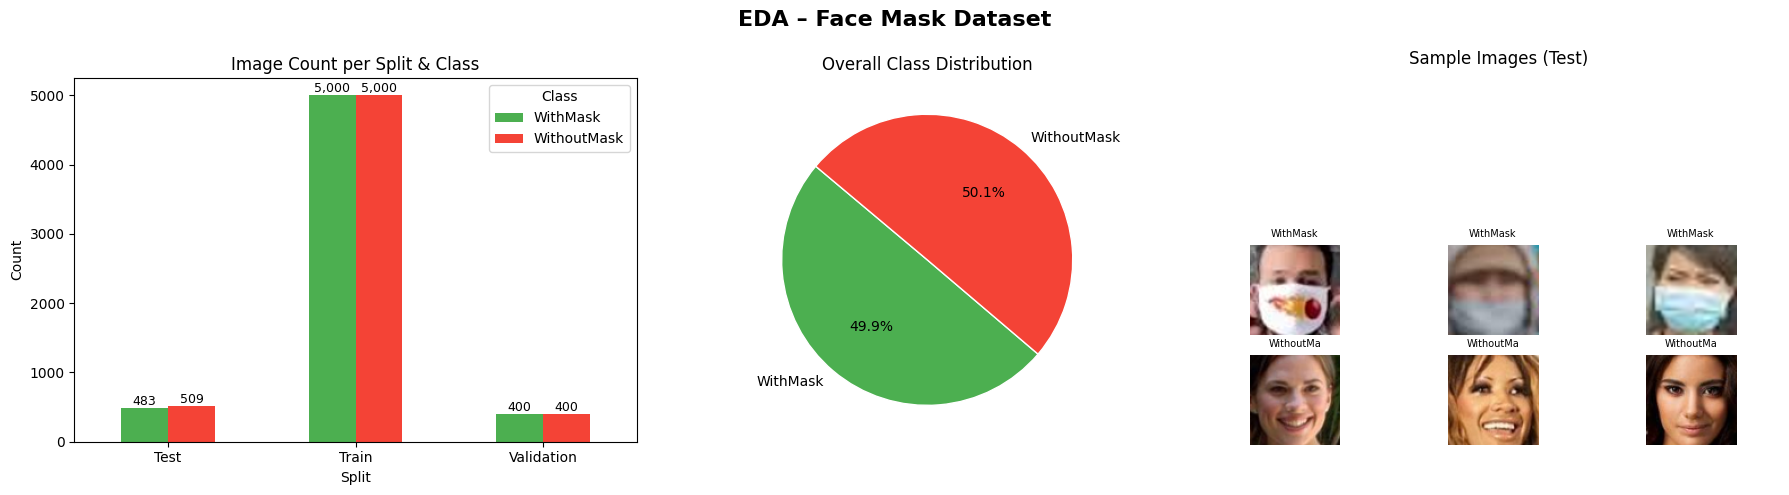

Saved: eda_overview.png

[2/7] Building Data Loaders …
  Splits : ['Test', 'Train', 'Validation']
  Classes: ['WithMask', 'WithoutMask']

Train: 10000 | Val: 800 | Test: 992
Classes: ['WithMask', 'WithoutMask']

[3/7] Building Partially Fine-Tuned ViT …


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



── ViT Model Summary ──
  Total params    : 85,996,034
  Trainable       : 7,286,786  (8.5%)
  Frozen          : 78,709,248

  Trainable groups (7):
    • vit.classifier.1.bias
    • vit.classifier.1.weight
    • vit.classifier.4.bias
    • vit.classifier.4.weight
    • vit.vit.encoder.layer.11
    • vit.vit.layernorm.bias
    • vit.vit.layernorm.weight

[4/7] Training …

  EPOCH 1/8
  Epoch 1 [50/313]  loss=0.5326  acc=75.2%
  Epoch 1 [100/313]  loss=0.4544  acc=80.7%
  Epoch 1 [150/313]  loss=0.4206  acc=83.0%
  Epoch 1 [200/313]  loss=0.3980  acc=84.5%
  Epoch 1 [250/313]  loss=0.3837  acc=85.4%
  Epoch 1 [300/313]  loss=0.3781  acc=86.2%

  ▶ Train  loss=0.3767  acc=86.13%
  ▶ Val    loss=0.3525  acc=99.50%
  ✔ Saved best model  (val_acc=99.50%)

  EPOCH 2/8
  Epoch 2 [50/313]  loss=0.3570  acc=90.1%
  Epoch 2 [100/313]  loss=0.3301  acc=86.7%
  Epoch 2 [150/313]  loss=0.3318  acc=87.9%
  Epoch 2 [200/313]  loss=0.3230  acc=87.2%
  Epoch 2 [250/313]  loss=0.3285  acc=88.0%
  Epoch

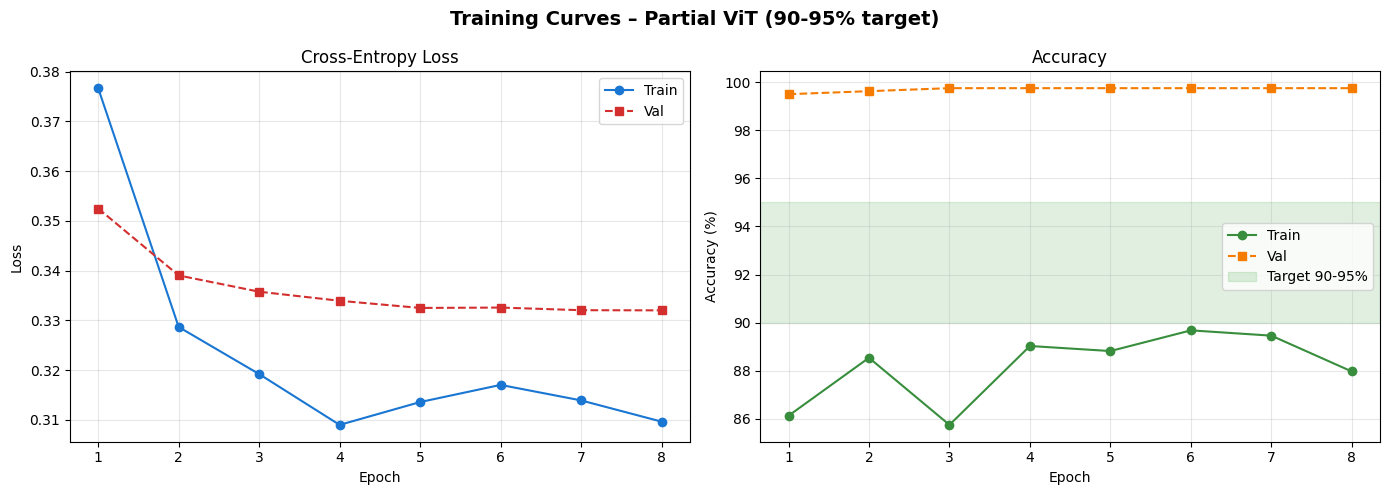

Saved: training_curves.png

[5/7] Evaluating on Test Set …
  Test Accuracy: 99.80%


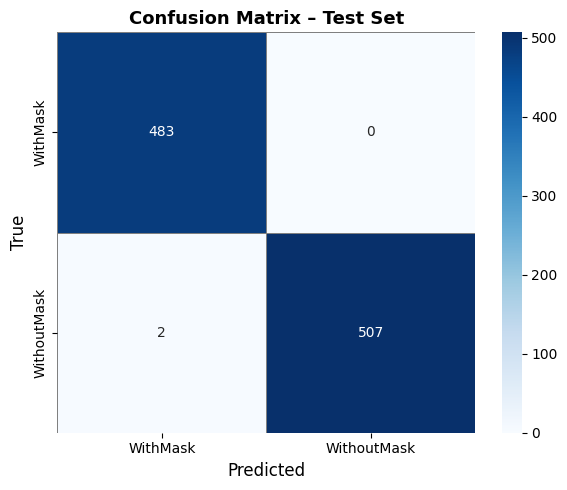

Saved: confusion_matrix.png


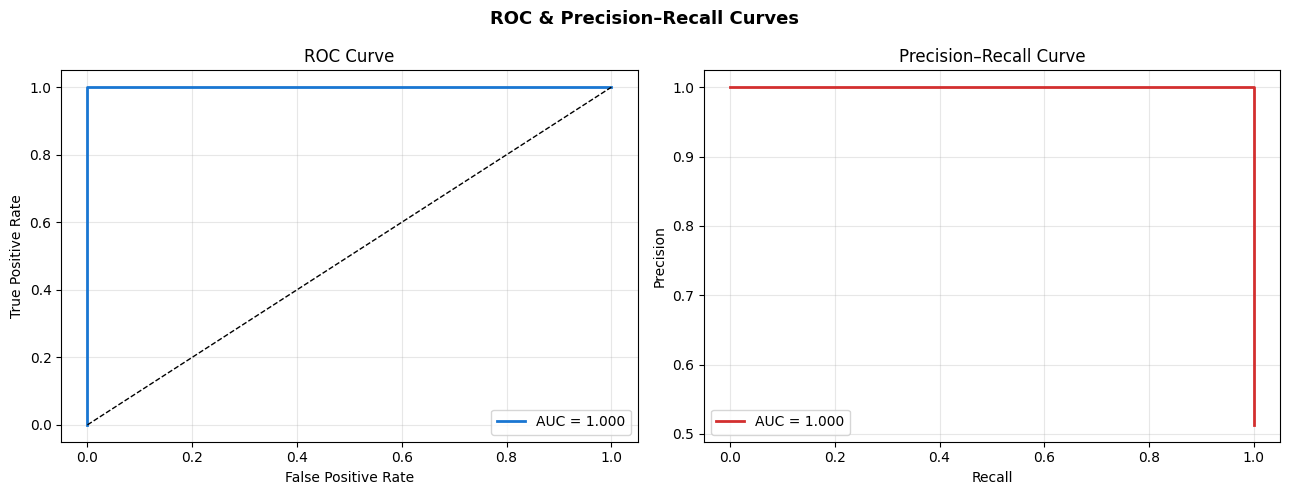

Saved: roc_pr_curves.png


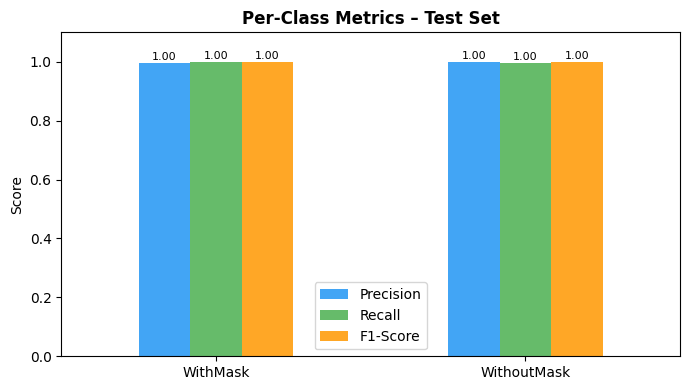

Saved: classification_report.png

── Classification Report ──
              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       483
 WithoutMask       1.00      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992



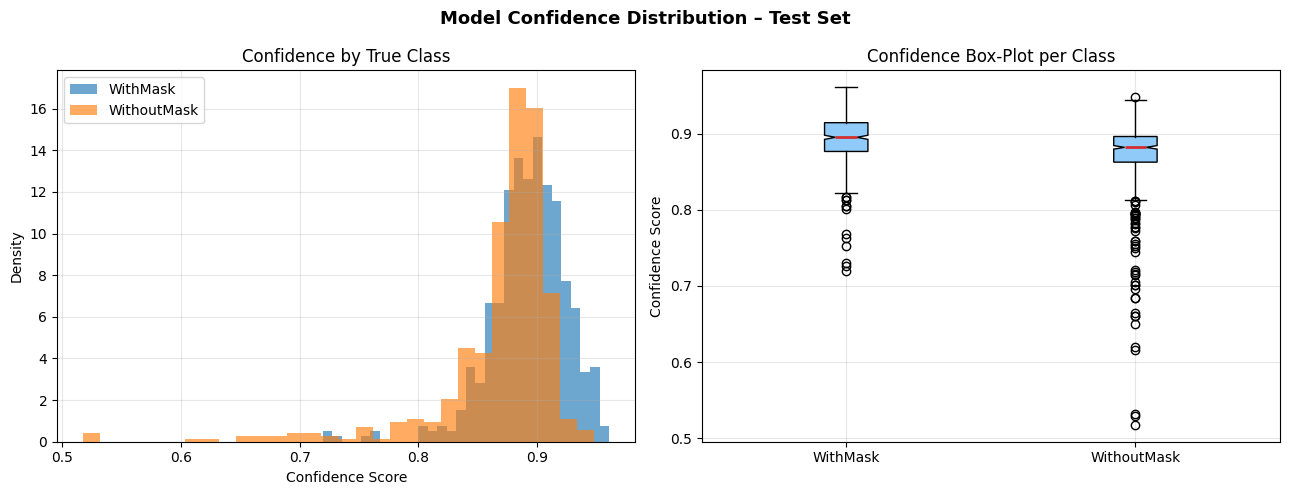

Saved: confidence_distribution.png

[6/7] Generating XAI Explanations …


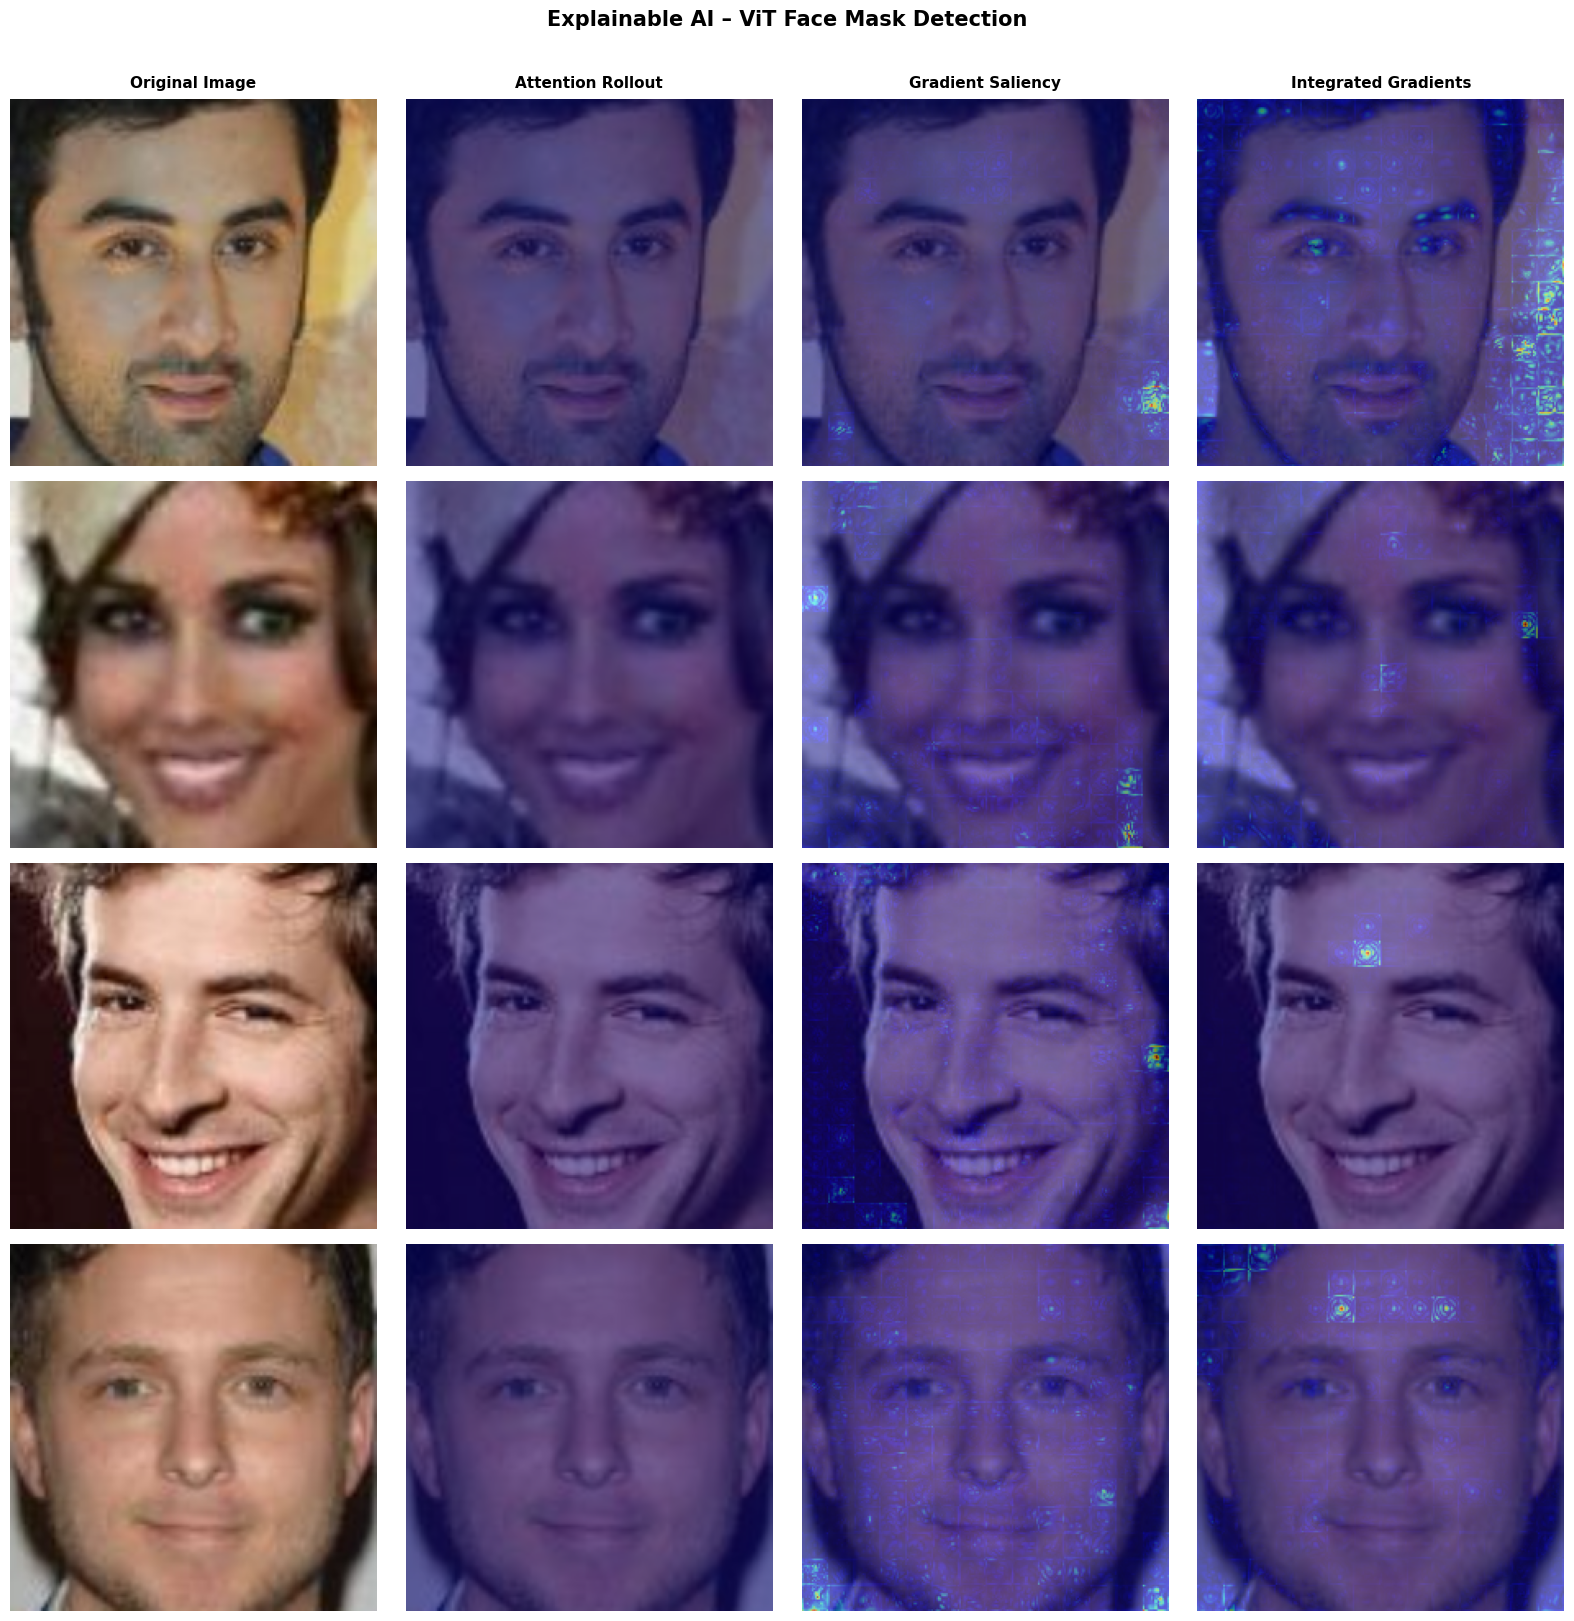

Saved: xai_explanations.png

[7/7] Per-Head Attention Analysis …
Could not capture attention weights.

  Pipeline Complete!  All outputs saved.
  • eda_overview.png
  • training_curves.png
  • confusion_matrix.png
  • roc_pr_curves.png
  • classification_report.png
  • confidence_distribution.png
  • xai_explanations.png
  • patch_attention_heads.png
  • best_vit_mask.pth


In [13]:
def main():
    print("=" * 65)
    print("  Face Mask Detection: Partial ViT + XAI  (target 90-95%)")
    print("=" * 65)

    # ── EDA ─────────────────────────────────────────────────────────────────
    print("\n[1/7] Exploratory Data Analysis …")
    _, _, root = find_dataset_structure(DATA_ROOT)
    plot_eda(root)

    # ── Data Loaders ─────────────────────────────────────────────────────────
    print("\n[2/7] Building Data Loaders …")
    train_loader, val_loader, test_loader = build_loaders(root)

    # ── Model ────────────────────────────────────────────────────────────────
    print("\n[3/7] Building Partially Fine-Tuned ViT …")
    model = PartialViT(num_classes=NUM_CLASSES, unfreeze_last_n=1).to(DEVICE)
    summarize_model(model)

    # ── Training ─────────────────────────────────────────────────────────────
    print("\n[4/7] Training …")
    history = run_training(model, train_loader, val_loader)
    plot_training_curves(history)

    # ── Test Evaluation ──────────────────────────────────────────────────────
    model.load_state_dict(torch.load("best_vit_mask.pth", map_location=DEVICE))
    print("\n[5/7] Evaluating on Test Set …")
    criterion = nn.CrossEntropyLoss()
    _, test_acc, y_pred, y_true, y_probs = evaluate(model, test_loader, criterion)
    print(f"  Test Accuracy: {100 * test_acc:.2f}%")

    plot_confusion_matrix(y_true, y_pred)
    plot_roc_pr(y_true, y_probs)
    plot_classification_report(y_true, y_pred)
    plot_confidence_distribution(model, test_loader)

    # ── XAI ─────────────────────────────────────────────────────────────────
    print("\n[6/7] Generating XAI Explanations …")
    plot_xai(model, test_loader, n_samples=4)

    print("\n[7/7] Per-Head Attention Analysis …")
    plot_patch_attention(model, test_loader)

    print("\n" + "=" * 65)
    print("  Pipeline Complete!  All outputs saved.")
    print("=" * 65)
    for fname in [
        "eda_overview.png", "training_curves.png",
        "confusion_matrix.png", "roc_pr_curves.png",
        "classification_report.png", "confidence_distribution.png",
        "xai_explanations.png", "patch_attention_heads.png",
        "best_vit_mask.pth",
    ]:
        print(f"  • {fname}")


if __name__ == "__main__":
    main()


### Download Model

In [14]:
from google.colab import files

files.download('best_vit_mask.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>